In [1]:
# ==============================================
# استيراد المكتبات المطلوبة للمشروع
# ==============================================

# TensorFlow و Keras (للبناء والتدريب)
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# للرسم والرسوم البيانية
import matplotlib.pyplot as plt
import seaborn as sns

# للعمليات الحسابية ومعالجة الصور
import numpy as np
import cv2
import os

# لتقييم النموذج
from sklearn.metrics import classification_report, confusion_matrix

print(" All libraries imported successfully!")

 All libraries imported successfully!


In [3]:
# ==============================================
# تحديد المسارات (على جهازك الشخصي)
# ==============================================

# مسار التدريب (جواه 4 فولدرات: glioma, meningioma, notumor, pituitary)
train_path = r"F:\HIT Academy\Second year\Second term\Graduation Project\Our project\Graduation_Project\Ordered\Train"

# مسار الاختبار (جواه 4 فولدرات: glioma, meningioma, notumor, pituitary)
test_path = r"F:\HIT Academy\Second year\Second term\Graduation Project\Our project\Graduation_Project\Ordered\test"

# طباعة المسارات للتأكد
print(f"Train path: {train_path}")
print(f"Test path: {test_path}")
print(f"Train path exists: {os.path.exists(train_path)}")
print(f"Test path exists: {os.path.exists(test_path)}")

# ==============================================
# إعدادات الصور
# ==============================================
img_size = (224, 224)   # حجم الصورة (عرض، ارتفاع)
batch_size = 32         # عدد الصور في كل دفعة

# ==============================================
# إنشاء مولد بيانات للتدريب (مع Augmentation)
# ==============================================
train_datagen = ImageDataGenerator(
    rescale=1./255,           # تطبيع قيم البكسلات من 0-255 لـ 0-1
    rotation_range=20,        # تدوير الصورة بزاوية عشوائية تصل لـ 20 درجة
    horizontal_flip=True,     # قلب الصورة أفقياً (يمين لشمال)
    brightness_range=[0.8, 1.2]  # تغيير سطوع الصورة بين 80% و 120%
)

# ==============================================
# إنشاء مولد بيانات للاختبار (تطبيع فقط، بدون Augmentation)
# ==============================================
test_datagen = ImageDataGenerator(
    rescale=1./255            # تطبيع قيم البكسلات من 0-255 لـ 0-1 فقط
)

# ==============================================
# تحميل بيانات التدريب
# ==============================================
train_generator = train_datagen.flow_from_directory(
    train_path,               # المسار
    target_size=img_size,     # تغيير حجم الصور لـ 224x224
    batch_size=batch_size,    # حجم الدفعة
    class_mode='categorical', # تصنيف متعدد الفئات
    shuffle=True              # خلط الصور عشوائياً
)

# ==============================================
# تحميل بيانات الاختبار
# ==============================================
test_generator = test_datagen.flow_from_directory(
    test_path,                # المسار
    target_size=img_size,     # تغيير حجم الصور لـ 224x224
    batch_size=batch_size,    # حجم الدفعة
    class_mode='categorical', # تصنيف متعدد الفئات
    shuffle=False             # عدم خلط الصور للتقييم الدقيق
)

# ==============================================
# طباعة معلومات الداتا
# ==============================================
print("\n📊 Classes and their indices:")
print(train_generator.class_indices)

print(f"\n📈 Number of training samples: {train_generator.samples}")
print(f"📈 Number of testing samples: {test_generator.samples}")

# عرض عدد الصور في كل فئة
print("\n📁 Training data distribution:")
for class_name in train_generator.class_indices.keys():
    class_path = os.path.join(train_path, class_name)
    num_images = len(os.listdir(class_path))
    print(f"   {class_name}: {num_images} images")

print("\n📁 Testing data distribution:")
for class_name in test_generator.class_indices.keys():
    class_path = os.path.join(test_path, class_name)
    num_images = len(os.listdir(class_path))
    print(f"   {class_name}: {num_images} images")

Train path: F:\HIT Academy\Second year\Second term\Graduation Project\Our project\Graduation_Project\Ordered\Train
Test path: F:\HIT Academy\Second year\Second term\Graduation Project\Our project\Graduation_Project\Ordered\test
Train path exists: True
Test path exists: True
Found 13356 images belonging to 4 classes.
Found 3340 images belonging to 4 classes.

📊 Classes and their indices:
{'glioma': 0, 'meningioma': 1, 'notumor': 2, 'pituitary': 3}

📈 Number of training samples: 13356
📈 Number of testing samples: 3340

📁 Training data distribution:
   glioma: 3339 images
   meningioma: 3339 images
   notumor: 3339 images
   pituitary: 3339 images

📁 Testing data distribution:
   glioma: 835 images
   meningioma: 835 images
   notumor: 835 images
   pituitary: 835 images


In [5]:
# ==============================================
# بناء نموذج التصنيف (4-conv-1-dense-1-dropout)
# ==============================================

# إنشاء نموذج Sequential (طبقات متتالية)
model = Sequential()

# طبقة المدخلات
model.add(Input(shape=(224, 224, 3)))

# ========== الطبقة الالتفافية الأولى ==========
# 32 فلتر، حجم 3x3، دالة ReLU
model.add(Conv2D(32, (3, 3), activation='relu', padding='same'))
model.add(MaxPooling2D((2, 2)))   # تقليل الحجم للنصف

# ========== الطبقة الالتفافية الثانية ==========
# 64 فلتر (ضعف اللي قبلي)
model.add(Conv2D(64, (3, 3), activation='relu', padding='same'))
model.add(MaxPooling2D((2, 2)))   # تقليل الحجم للنصف

# ========== الطبقة الالتفافية الثالثة ==========
# 128 فلتر
model.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
model.add(MaxPooling2D((2, 2)))   # تقليل الحجم للنصف

# ========== الطبقة الالتفافية الرابعة ==========
# 128 فلتر
model.add(Conv2D(128, (3, 3), activation='relu', padding='same'))
model.add(MaxPooling2D((2, 2)))   # تقليل الحجم للنصف

# ========== طبقة الفرد (Flatten) ==========
# تحويل المصفوفة 2D إلى 1D عشان تدخل على الطبقات الكاملة
model.add(Flatten())

# ========== الطبقة المتصلة بالكامل ==========
model.add(Dense(512, activation='relu'))

# ========== طبقة الإسقاط (Dropout) ==========
# بتسقط 50% من الخلايا عشوائياً لمنع Overfitting
model.add(Dropout(0.5))

# ========== طبقة الإخراج ==========
# 4 فئات، دالة Softmax لتحويل الأرقام لاحتمالات
model.add(Dense(4, activation='softmax'))

# ==============================================
# عرض ملخص النموذج
# ==============================================
model.summary()

# ==============================================
# تجميع النموذج (تحديد طريقة التدريب)
# ==============================================
model.compile(
    optimizer='adam',                    # محسن Adam
    loss='categorical_crossentropy',    # دالة الخسارة للتصنيف المتعدد
    metrics=['accuracy']                # المقياس اللي هنقيم بيه
)

print("\n✅ Model built and compiled successfully!")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 224, 224, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 112, 112, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 112, 112, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 56, 56, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 56, 56, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 28, 28, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 28, 28, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │      12,845,568 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 4)                   │           2,052 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 13,088,452 (49.93 MB)

 Trainable params: 13,088,452 (49.93 MB)

 Non-trainable params: 0 (0.00 B)


✅ Model built and compiled successfully!


In [7]:
# ==============================================
# إعداد إضافات التدريب (Callbacks)
# ==============================================

# ModelCheckpoint: لحفظ أفضل نموذج أثناء التدريب
checkpoint = ModelCheckpoint(
    'best_classification_model.keras',  # اسم الملف اللي هيتحفظ
    monitor='val_accuracy',              # المقياس اللي هنراقبه
    save_best_only=True,                 # نحفظ أفضل نموذج بس
    mode='max'                           # أعلى قيمة accuracy هي الأحسن
)

# EarlyStopping: لإيقاف التدريب لو النتيجة وقفت تتحسن
early_stop = EarlyStopping(
    monitor='val_loss',      # المقياس اللي هنراقبه (الخسارة)
    patience=5,              # عدد المرات اللي نستنيها قبل ما نوقف
    restore_best_weights=True  # نرجع لأحسن أوزان
)

# ==============================================
# تدريب النموذج
# ==============================================
history = model.fit(
    train_generator,                    # بيانات التدريب
    validation_data=test_generator,     # بيانات الاختبار (للتقييم)
    epochs=20,                          # عدد مرات التدريب الكاملة
    callbacks=[checkpoint, early_stop], # الإضافات اللي عملناها
    verbose=1                           # عرض تفاصيل التدريب
)

# حفظ النموذج النهائي بعد التدريب
model.save('classification_model_final.keras')

print("\n✅ Model training completed and saved!")

C:\Users\HP\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
418/418 ━━━━━━━━━━━━━━━━━━━━ 1011s 2s/step - accuracy: 0.5989 - loss: 0.9439 - val_accuracy: 0.7754 - val_loss: 0.5454
Epoch 2/20
418/418 ━━━━━━━━━━━━━━━━━━━━ 600s 1s/step - accuracy: 0.8122 - loss: 0.4934 - val_accuracy: 0.8892 - val_loss: 0.3098
Epoch 3/20
418/418 ━━━━━━━━━━━━━━━━━━━━ 620s 1s/step - accuracy: 0.8850 - loss: 0.3223 - val_accuracy: 0.9096 - val_loss: 0.2460
Epoch 4/20
418/418 ━━━━━━━━━━━━━━━━━━━━ 434s 1s/step - accuracy: 0.9210 - loss: 0.2243 - val_accuracy: 0.9404 - val_loss: 0.1820
Epoch 5/20
418/418 ━━━━━━━━━━━━━━━━━━━━ 311s 744ms/step - accuracy: 0.9416 - loss: 0.1730 - val_accuracy: 0.9485 - val_loss: 0.1605
Epoch 6/20
418/418 ━━━━━━━━━━━━━━━━━━━━ 349s 836ms/step - accuracy: 0.9522 - loss: 0.1395 - val_accuracy: 0.9704 - val_loss: 0.1187
Epoch 7/20
418/418 ━━━━━━━━━━━━━━━━━━━━ 341s 816ms/step - accuracy: 0.9622 - loss: 0.1170 - val_accuracy: 0.9763 - val_loss: 0.0900
Epoch 8/20
418/418 ━━━━━━━━━━━━━━━━━━━━ 336s 803ms/step - accuracy: 0.9653 - loss: 0.09

105/105 ━━━━━━━━━━━━━━━━━━━━ 29s 276ms/step - accuracy: 0.9825 - loss: 0.0729

 Model accuracy on the test: 0.9847 (98.47%)
 Form loss: 0.0594


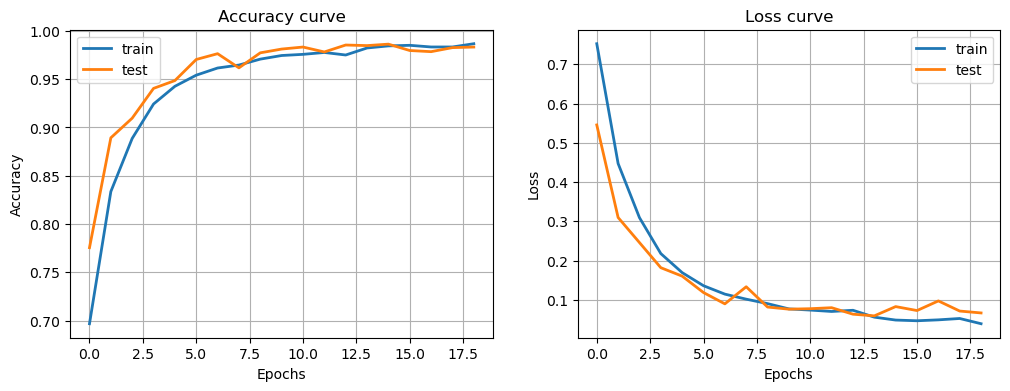

105/105 ━━━━━━━━━━━━━━━━━━━━ 28s 266ms/step


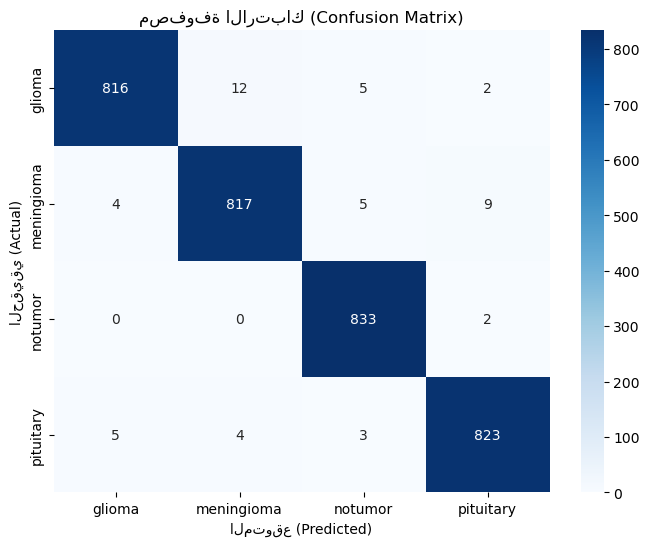


 Classification report for each category:
              precision    recall  f1-score   support

      glioma       0.99      0.98      0.98       835
  meningioma       0.98      0.98      0.98       835
     notumor       0.98      1.00      0.99       835
   pituitary       0.98      0.99      0.99       835

    accuracy                           0.98      3340
   macro avg       0.98      0.98      0.98      3340
weighted avg       0.98      0.98      0.98      3340

 تم تقييم موديل التصنيف بنجاح


In [11]:
# ==============================================
# بوكس 5: تقييم موديل التصنيف وعرض النتائج
# ==============================================

# تقييم النموذج على بيانات الاختبار
test_loss, test_acc = model.evaluate(test_generator)
print(f"\n Model accuracy on the test: {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f" Form loss: {test_loss:.4f}")

# ===== رسم Accuracy و Loss أثناء التدريب =====
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# رسم Accuracy
ax1.plot(history.history['accuracy'], label='train', linewidth=2)
ax1.plot(history.history['val_accuracy'], label='test', linewidth=2)
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.set_title('Accuracy curve')
ax1.grid(True)

# رسم Loss
ax2.plot(history.history['loss'], label='train', linewidth=2)
ax2.plot(history.history['val_loss'], label='test', linewidth=2)
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.set_title('Loss curve')
ax2.grid(True)

plt.savefig('training_curves.png', dpi=300)
plt.show()

# ===== رسم Confusion Matrix =====
# التنبؤ على جميع صور الاختبار
y_pred = model.predict(test_generator)
y_pred_classes = y_pred.argmax(axis=1)  # تحويل احتمالات لأرقام
y_true = test_generator.classes          # القيم الحقيقية
class_names = list(test_generator.class_indices.keys())

# حساب مصفوفة الارتباك
cm = confusion_matrix(y_true, y_pred_classes)

# رسمها
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.savefig('confusion_matrix.png', dpi=300)
plt.show()

# ===== تقرير كامل لكل فئة =====
print("\n Classification report for each category:")
print("="*50)
print(classification_report(y_true, y_pred_classes, target_names=class_names))

print(" تم تقييم موديل التصنيف بنجاح")


Testing one image from each class:


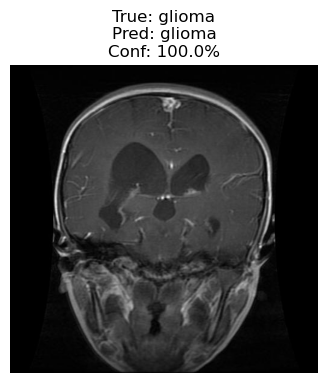

  glioma: CORRECT (100.00%)


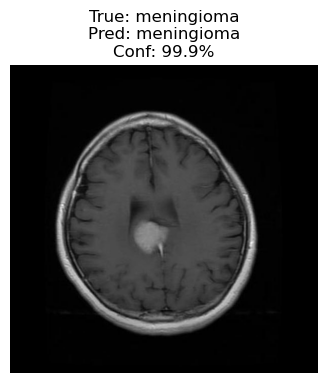

  meningioma: CORRECT (99.91%)


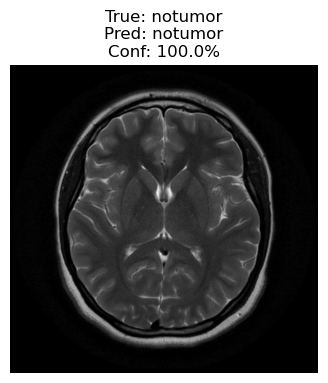

  notumor: CORRECT (100.00%)


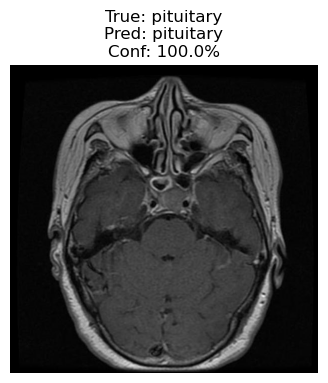

  pituitary: CORRECT (100.00%)

Test on a single image:

 Classification model testing completed!


In [13]:
# ==============================================
# Box 6: Test Classification Model on New Images
# ==============================================

# List of class names (same order as training)
class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']

# ===== Function to test a single image =====
def test_one_image(image_path):
    """
    Test the model on a single image and display result
    """
    # 1. Read image
    img = cv2.imread(image_path)
    
    # 2. Check if image exists
    if img is None:
        print(f"ERROR: Image not found at: {image_path}")
        return None, None
    
    # 3. Process image (same steps as training)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_resized = cv2.resize(img_rgb, (224, 224))
    img_normalized = img_resized / 255.0
    img_input = np.expand_dims(img_normalized, axis=0)
    
    # 4. Predict
    prediction = model.predict(img_input, verbose=0)
    predicted_class = class_names[prediction.argmax()]
    confidence = prediction.max() * 100
    
    # 5. Display image with result
    plt.figure(figsize=(6, 6))
    plt.imshow(img_rgb)
    plt.axis('off')
    plt.title(f'Predicted: {predicted_class}\nConfidence: {confidence:.2f}%', 
              fontsize=14, fontweight='bold')
    plt.show()
    
    # 6. Print result
    print(f"\nImage: {image_path}")
    print(f"Predicted Tumor Type: {predicted_class}")
    print(f"Confidence: {confidence:.2f}%")
    
    # 7. Show probabilities for each class
    print("\nProbabilities for each class:")
    print("-" * 40)
    for i, class_name in enumerate(class_names):
        bar_length = int(prediction[0][i] * 30)
        bar = "█" * bar_length + "░" * (30 - bar_length)
        print(f"   {class_name:12s}: {bar} {prediction[0][i]*100:.2f}%")
    
    return predicted_class, confidence


# ===== Function to test a folder of images =====
def test_folder(folder_path):
    """
    Test the model on all images in a folder and show summary
    """
    # Get all image files in folder
    image_extensions = ('.jpg', '.jpeg', '.png', '.bmp', '.tiff')
    image_files = [f for f in os.listdir(folder_path) 
                   if f.lower().endswith(image_extensions)]
    
    if len(image_files) == 0:
        print(f"No images found in folder: {folder_path}")
        return
    
    print(f"\nTesting {len(image_files)} images from: {folder_path}")
    print("=" * 60)
    
    results = []
    for img_file in image_files:
        img_path = os.path.join(folder_path, img_file)
        
        # Process image
        img = cv2.imread(img_path)
        if img is None:
            print(f"SKIP: Cannot read {img_file}")
            continue
            
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img_resized = cv2.resize(img_rgb, (224, 224))
        img_normalized = img_resized / 255.0
        img_input = np.expand_dims(img_normalized, axis=0)
        
        # Predict
        prediction = model.predict(img_input, verbose=0)
        predicted_class = class_names[prediction.argmax()]
        confidence = prediction.max() * 100
        
        results.append({
            'image': img_file,
            'predicted_class': predicted_class,
            'confidence': confidence
        })
        
        print(f"  {img_file}: {predicted_class} ({confidence:.2f}%)")
    
    return results


# ===== Function to test one image from each class =====
def test_one_from_each_class(test_path):
    """
    Test one image from each class folder to verify model performance
    """
    print("\n" + "=" * 50)
    print("Testing one image from each class:")
    print("=" * 50)
    
    for class_name in class_names:
        class_folder = os.path.join(test_path, class_name)
        if os.path.exists(class_folder):
            # Get first image in folder
            images = [f for f in os.listdir(class_folder) 
                     if f.endswith(('.jpg', '.png', '.jpeg'))]
            if images:
                test_image = os.path.join(class_folder, images[0])
                
                # Process image
                img = cv2.imread(test_image)
                img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img_resized = cv2.resize(img_rgb, (224, 224))
                img_input = np.expand_dims(img_resized / 255.0, axis=0)
                
                # Predict
                prediction = model.predict(img_input, verbose=0)
                predicted = class_names[prediction.argmax()]
                confidence = prediction.max() * 100
                
                # Display
                plt.figure(figsize=(4, 4))
                plt.imshow(img_rgb)
                plt.axis('off')
                plt.title(f'True: {class_name}\nPred: {predicted}\nConf: {confidence:.1f}%')
                plt.show()
                
                if predicted == class_name:
                    print(f"  {class_name}: CORRECT ({confidence:.2f}%)")
                else:
                    print(f"  {class_name}: WRONG (Predicted: {predicted})")


# ===== RUN TESTS =====

# Test 1: One image from each class (most important)
test_one_from_each_class(test_path)

# Test 2: Single image (change the path to your test image)
print("\n" + "=" * 50)
print("Test on a single image:")
print("=" * 50)

# Change this path to your own test image
test_image_path = r"F:\path\to\your\test\image.jpg"

# Uncomment the line below after changing the path
# test_one_image(test_image_path)

# Test 3: Test a full folder (optional)
# print("\n" + "=" * 50)
# print("Test on a folder:")
# print("=" * 50)
# folder_path = r"F:\path\to\test\folder"
# results = test_folder(folder_path)

print("\n Classification model testing completed!")

# بداية نموذج ال Segmenatation

In [15]:
# ==============================================
# Box 7: Build U-Net Model for Segmentation
# ==============================================

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D, Concatenate
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import matplotlib.pyplot as plt
import numpy as np
import cv2
import os

print("=" * 50)
print("BOX 7: Building U-Net Model for Segmentation")
print("=" * 50)

def build_unet(input_size=(224, 224, 3)):
    """
    Build U-Net model for brain tumor segmentation
    Input: MRI image (224, 224, 3)
    Output: Binary mask (224, 224, 1) where white = tumor, black = background
    """
    
    inputs = Input(input_size)
    
    # ========== ENCODER (Contracting Path) ==========
    
    # Level 1
    c1 = Conv2D(64, (3, 3), activation='relu', padding='same')(inputs)
    c1 = Conv2D(64, (3, 3), activation='relu', padding='same')(c1)
    p1 = MaxPooling2D((2, 2))(c1)
    
    # Level 2
    c2 = Conv2D(128, (3, 3), activation='relu', padding='same')(p1)
    c2 = Conv2D(128, (3, 3), activation='relu', padding='same')(c2)
    p2 = MaxPooling2D((2, 2))(c2)
    
    # Level 3
    c3 = Conv2D(256, (3, 3), activation='relu', padding='same')(p2)
    c3 = Conv2D(256, (3, 3), activation='relu', padding='same')(c3)
    p3 = MaxPooling2D((2, 2))(c3)
    
    # Level 4
    c4 = Conv2D(512, (3, 3), activation='relu', padding='same')(p3)
    c4 = Conv2D(512, (3, 3), activation='relu', padding='same')(c4)
    p4 = MaxPooling2D((2, 2))(c4)
    
    # Level 5 (Bottleneck)
    c5 = Conv2D(1024, (3, 3), activation='relu', padding='same')(p4)
    c5 = Conv2D(1024, (3, 3), activation='relu', padding='same')(c5)
    
    # ========== DECODER (Expanding Path) ==========
    
    # Level 5 up
    u6 = UpSampling2D((2, 2))(c5)
    u6 = Concatenate()([u6, c4])
    c6 = Conv2D(512, (3, 3), activation='relu', padding='same')(u6)
    c6 = Conv2D(512, (3, 3), activation='relu', padding='same')(c6)
    
    # Level 4 up
    u7 = UpSampling2D((2, 2))(c6)
    u7 = Concatenate()([u7, c3])
    c7 = Conv2D(256, (3, 3), activation='relu', padding='same')(u7)
    c7 = Conv2D(256, (3, 3), activation='relu', padding='same')(c7)
    
    # Level 3 up
    u8 = UpSampling2D((2, 2))(c7)
    u8 = Concatenate()([u8, c2])
    c8 = Conv2D(128, (3, 3), activation='relu', padding='same')(u8)
    c8 = Conv2D(128, (3, 3), activation='relu', padding='same')(c8)
    
    # Level 2 up
    u9 = UpSampling2D((2, 2))(c8)
    u9 = Concatenate()([u9, c1])
    c9 = Conv2D(64, (3, 3), activation='relu', padding='same')(u9)
    c9 = Conv2D(64, (3, 3), activation='relu', padding='same')(c9)
    
    # Output layer (sigmoid for binary classification)
    outputs = Conv2D(1, (1, 1), activation='sigmoid')(c9)
    
    model = Model(inputs=inputs, outputs=outputs)
    return model

# Create the model
unet_model = build_unet((224, 224, 3))

# Compile the model
unet_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', 'iou_score']
)

# Display model summary
unet_model.summary()

print("\n U-Net model built and compiled successfully!")

BOX 7: Building U-Net Model for Segmentation


Model: "functional_12"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)    │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_4 (Conv2D)             │ (None, 224, 224, 64)      │           1,792 │ input_layer_1[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_5 (Conv2D)             │ (None, 224, 224, 64)      │          36,928 │ conv2d_4[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_4               │ (None, 112, 112, 64)      │               0 │ conv2d_5[0][0]             │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_6 (Conv2D)             │ (None, 112, 112, 128)     │          73,856 │ max_pooling2d_4[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_7 (Conv2D)             │ (None, 112, 112, 128)     │         147,584 │ conv2d_6[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_5               │ (None, 56, 56, 128)       │               0 │ conv2d_7[0][0]             │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_8 (Conv2D)             │ (None, 56, 56, 256)       │         295,168 │ max_pooling2d_5[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_9 (Conv2D)             │ (None, 56, 56, 256)       │         590,080 │ conv2d_8[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_6               │ (None, 28, 28, 256)       │               0 │ conv2d_9[0][0]             │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_10 (Conv2D)            │ (None, 28, 28, 512)       │       1,180,160 │ max_pooling2d_6[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_11 (Conv2D)            │ (None, 28, 28, 512)       │       2,359,808 │ conv2d_10[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ max_pooling2d_7               │ (None, 14, 14, 512)       │               0 │ conv2d_11[0][0]            │
│ (MaxPooling2D)                │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_12 (Conv2D)            │ (None, 14, 14, 1024)      │       4,719,616 │ max_pooling2d_7[0][0]      │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv2d_13 (Conv2D)            │ (None, 14, 14, 1024)      │       9,438,208 │ conv2d_12[0][0]            │
├───────────────────────────────┼───────────────────────────┼───────────────

 Total params: 31,378,945 (119.70 MB)

 Trainable params: 31,378,945 (119.70 MB)

 Non-trainable params: 0 (0.00 B)


 U-Net model built and compiled successfully!



BOX 8: Loading Segmentation Data

----------------------------------------
Loading TRAINING data...

Loading 3933 images from: F:\HIT Academy\Second year\Second term\Graduation Project\Our project\Graduation_Project\brisc2025\segmentation_task\train\images
  Loaded 500/3933 images
  Loaded 1000/3933 images
  Loaded 1500/3933 images
  Loaded 2000/3933 images
  Loaded 2500/3933 images
  Loaded 3000/3933 images
  Loaded 3500/3933 images
Successfully loaded 3933 image-mask pairs

----------------------------------------
Loading TESTING data...

Loading 860 images from: F:\HIT Academy\Second year\Second term\Graduation Project\Our project\Graduation_Project\brisc2025\segmentation_task\test\images
  Loaded 500/860 images
Successfully loaded 860 image-mask pairs

DATA LOADING COMPLETE
Training images: (3933, 224, 224, 3)
Training masks: (3933, 224, 224, 1)
Testing images: (860, 224, 224, 3)
Testing masks: (860, 224, 224, 1)


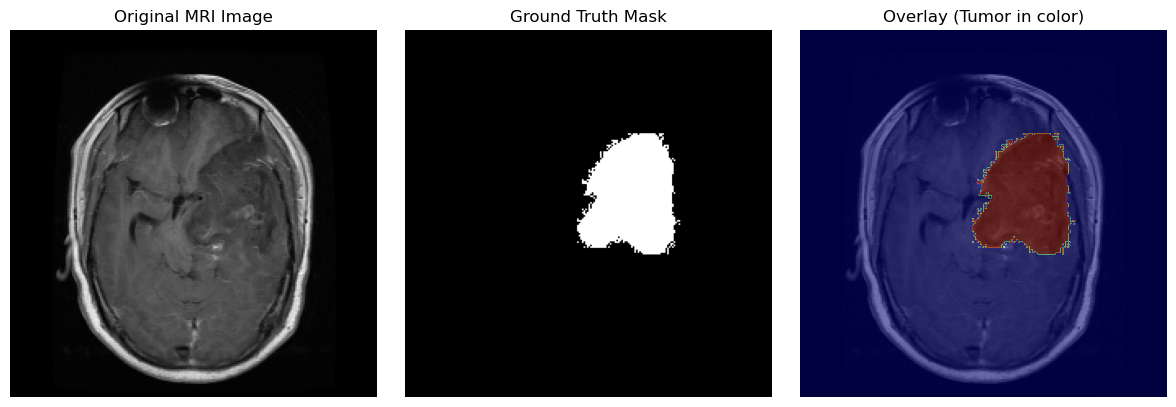


 Sample visualization saved as 'segmentation_sample.png'


In [19]:
# Box 8: Load Segmentation Data from BRISC Dataset (Corrected)
print("\n" + "=" * 50)
print("BOX 8: Loading Segmentation Data")
print("=" * 50)

# Paths to BRISC dataset
base_path = r"F:\HIT Academy\Second year\Second term\Graduation Project\Our project\Graduation_Project\brisc2025\segmentation_task"

train_images_path = os.path.join(base_path, "train", "images")
train_masks_path = os.path.join(base_path, "train", "masks")
test_images_path = os.path.join(base_path, "test", "images")
test_masks_path = os.path.join(base_path, "test", "masks")

def load_segmentation_data(images_folder, masks_folder, img_size=(224, 224), limit=None):
    images = []
    masks = []
    
    # Get all image files
    image_files = [f for f in os.listdir(images_folder) if f.endswith(('.jpg', '.png', '.jpeg'))]
    
    if limit:
        image_files = image_files[:limit]
    
    print(f"\nLoading {len(image_files)} images from: {images_folder}")
    
    for i, img_file in enumerate(image_files):
        # 1. Load Image
        img_path = os.path.join(images_folder, img_file)
        img = cv2.imread(img_path)
        
        if img is None:
            print(f"Warning: Could not load {img_file}")
            continue
        
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        img = cv2.resize(img, img_size)
        img = img / 255.0
        images.append(img)
        
        # 2. Load Mask (Fixed Logic)
        # The mask has the SAME name as the image, but with .png extension
        name_only = os.path.splitext(img_file)[0]  # Remove .jpg extension
        mask_file = name_only + ".png"             # Add .png extension
        mask_path = os.path.join(masks_folder, mask_file)
        
        if os.path.exists(mask_path):
            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
            mask = cv2.resize(mask, img_size)
            # Binarize mask (values > 0 become 1, background 0)
            mask = (mask > 0).astype(np.float32)
            mask = np.expand_dims(mask, axis=-1)
            masks.append(mask)
        else:
            print(f"Warning: Mask not found for {img_file}")
            continue
        
        if (i + 1) % 500 == 0:
            print(f"  Loaded {i + 1}/{len(image_files)} images")
    
    print(f"Successfully loaded {len(images)} image-mask pairs")
    return np.array(images), np.array(masks)

# Load training data
print("\n" + "-" * 40)
print("Loading TRAINING data...")
X_train, y_train = load_segmentation_data(train_images_path, train_masks_path, limit=None)

# Load testing data
print("\n" + "-" * 40)
print("Loading TESTING data...")
X_test, y_test = load_segmentation_data(test_images_path, test_masks_path, limit=None)

print("\n" + "=" * 40)
print("DATA LOADING COMPLETE")
print(f"Training images: {X_train.shape}")
print(f"Training masks: {y_train.shape}")
print(f"Testing images: {X_test.shape}")
print(f"Testing masks: {y_test.shape}")

# Visualize a sample
sample_idx = 0
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 4))

ax1.imshow(X_train[sample_idx])
ax1.set_title('Original MRI Image')
ax1.axis('off')

ax2.imshow(y_train[sample_idx].squeeze(), cmap='gray')
ax2.set_title('Ground Truth Mask')
ax2.axis('off')

# Overlay
ax3.imshow(X_train[sample_idx])
ax3.imshow(y_train[sample_idx].squeeze(), cmap='jet', alpha=0.5)
ax3.set_title('Overlay (Tumor in color)')
ax3.axis('off')

plt.tight_layout()
plt.savefig('segmentation_sample.png', dpi=300)
plt.show()

print("\n Sample visualization saved as 'segmentation_sample.png'")

In [25]:
# ==============================================
# Box 8.5: Check Data Shapes and Fix
# ==============================================

print("=" * 50)
print("Checking data shapes...")
print("=" * 50)

print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

# Check unique values in masks
print("\nUnique values in training masks:")
print(f"  Min: {y_train.min():.4f}")
print(f"  Max: {y_train.max():.4f}")
print(f"  Unique: {np.unique(y_train)}")

# Ensure masks are binary (0 and 1)
print("\nFixing masks to binary (0 and 1)...")
y_train = (y_train > 0.5).astype(np.float32)
y_test = (y_test > 0.5).astype(np.float32)

print(f"After fix - y_train min: {y_train.min()}, max: {y_train.max()}")

# Check if output layer of model matches mask shape
print("\n" + "=" * 50)
print("Model output shape check:")
print("=" * 50)
print(f"Model output shape: {unet_model.output_shape}")
print(f"Expected mask shape: (None, 224, 224, 1)")

# Recompile model to be safe
unet_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("\n Data shapes verified and model recompiled!")

Checking data shapes...
X_train shape: (3933, 224, 224, 3)
y_train shape: (3933, 224, 224, 1)
X_test shape: (860, 224, 224, 3)
y_test shape: (860, 224, 224, 1)

Unique values in training masks:
  Min: 0.0000
  Max: 1.0000
  Unique: [0. 1.]

Fixing masks to binary (0 and 1)...
After fix - y_train min: 0.0, max: 1.0

Model output shape check:
Model output shape: (None, 224, 224, 1)
Expected mask shape: (None, 224, 224, 1)

 Data shapes verified and model recompiled!


In [35]:
print(f"X_train shape: {X_train.shape if 'X_train' in dir() else 'Not found'}")
print(f"X_test shape: {X_test.shape if 'X_test' in dir() else 'Not found'}")
print(f"unet_model: {'Found' if 'unet_model' in dir() else 'Not found'}")

X_train shape: (3933, 224, 224, 3)
X_test shape: (860, 224, 224, 3)
unet_model: Found
